## Introduction

To improve our model(s), we could spend a while trying different configurations, adding more layers, changing the learning rate, adjusting the number of neurons per layer and more.

`Transfer Learning:-` Taking the `patterns` (also called `weights`) another model has learned from another problem and using them for our own problem.

There are two main benefits of using transfer learning:

* Can Leverage an existing neural network architecture proven to work on problems similar to our own.

* Can Leverage a working neural working architecture which has `already learned` patterns on similar data to our own. This oftern results in achieving great results with less custom data.

What this means is, instead of hand-crafting our own neural network architectures or building them from scratch, we can utilise models which have worked for others.

And instead of training our own models from scratch on our own datasets, we can take the patterns a model has learned from datasets such as `ImageNet` (millions of images of different objects) and use them as the foundation of our own. Doing this often leads to getting great results with less data.






In [ ]:
# Add timestamp.

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

### Using a GPU

In [ ]:
# Are we using a GPU ?
!nvidia-smi

### Transfer learning with TensorFlow Hub: Getting great results with 10% of the data.

[TensorFlow Hub](https://www.kaggle.com/models?tfhub-redirect=true) --> Is a repository for existing model components. It allows us to import and use a fully trained model with as little as a URL.

Transfer learning often allows us to get great results with less data.



### Downloading and becoming one with the data

In [ ]:
# Get data (10% of labels)
import zipfile

# Download the data.
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# Unzip the downloaded fle.
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip", "r")
zip_ref.extractall()
zip_ref.close()

In [ ]:
# How many images in each folders ?
import os

# Walk through 10 percent data directory and list number of files.
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

### Creating data loaders (preparing the data)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

# Making an train and test sets of the dataset.
train_dir = "/content/10_food_classes_10_percent/train"
test_dir = "/content/10_food_classes_10_percent/test"

#
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

#
print("Training Images.")
train_data_10_percent = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode="categorical" # sine we are performing the multi-class classification so.
)

# In testing data, we cannot apply data augmentation.
print("Testing Images.")
test_data = train_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Now, we can see that we have got `750 images` in the training dataset belonging to `10 classses` (`75 per class`) and `2500 images` in the test set belonging to `10 classes` (`250 per class`).

### Setting up callbacks (things to run whilst our model trains).

`callbacks` -- Extra functionality that we can add to our models to be performed during or after training.

Some of the Most Important Callbacks are as:

* `Experiment Tracking with TensorBoard:-` Log the performance of multiple models and then view and compare these models in a visual ways on TensorBoard (a dashboard for inspecting neural netwok parameters). Helpful to compare the results of different models on our data.

* `Model Checkpointing`: save the model as it trains so that we can stop training if needed and come back to continue off where we have left training. Helpful it training takes a long time and can't be done in one sitting.

* `Early Stopping`: Leave a model training for an arbitary amount of time and have it stop training automatically when it cease to improve. Helpful when we have got a larger dataset and don't know how long training will take.

The TensorBoard callback can be accessed using [tf.keras.callbacks.TensorBoard()](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/TensorBoard).

 * The main functionality is saving a model's training performance metrics to a specified `log_dir`.

 By default, logs are recorded every epoch using the `update_fre='epoch'` parameter. This is a good default since tracking model performance too often can slow down model training.

 To track our modelling experiments using TensorBoard, Let's create a function which creates a TensorBoard callback for us.

 > 🔑 `Note:-`  We create a function for creating a `TensorBoard callback` because as we'll see later on, each model needs its own TensorBoard callback instance (so the function will create a new one each time it's run).

In [ ]:
# Create tensorboard callback (functionized because need to create a new one for each model).

import datetime
from tensorflow.keras.callbacks import TensorBoard

def create_tensorboard_callback(dir_name, experiment_name):

    """
    Saving a model's performance logs to a directory named such as:
    [dir_name]/[experiment_name]/[current_timestamp]

    dir_name :- Overall logs directory.
    experiment_name :- Name of a Particular experiment.
    current_timestamp :- The time that experiment started based on Python's datetime.datetime().now()
    """

    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    tensorboard_callback = Tensorboard(
        log_dirl=log_dir
    )

    print(f"Saving Tensorboard log files to: {log_dir}")

    return tensorboard_callback

### Creating models using TensorFlow Hub

---
In the past we've used `TensorFlow` to create our own `models layer by layer from scratch`.

Now we're going to do a similar process, except the majority of our model's layers are going to come from `TensorFlow Hub`.

In fact, we're going to use two models from TensorFlow Hub:

* [ResNetV2](https://arxiv.org/abs/1603.05027): a state of the art computer vision model architecture from 2016.

* [EfficientNet](https://arxiv.org/abs/1905.11946) :a state of the art computer vision architecture from 2019.


`State of the art` means that at some point, both of these models have achieved the lowest error rate on `ImageNet` [(ILSVRC-2012-CLS)](https://www.image-net.org/update-mar-11-2021.php), the gold standard of computer vision benchmarks.

---

Differnet types of transfer learning come into play, as is, `feature extraction` and `fine-tuning`.

1. "As is" `transfer learning` is when you take a `pretrained model` as it is and apply it to your task without any changes.

    * For example, many computer vision models are pretrained on the ImageNet dataset which contains 1000 different classes of images. This means passing a single image to this model will produce 1000 different prediction probability values (1 for each class).
    
    * This is helpful if you have 1000 classes of image you'd like to classify and they're all the same as the ImageNet classes, however, it's not helpful if you want to classify only a small subset of classes (such as 10 different kinds of food). Model's with `"/classification"` in their name on TensorFlow Hub provide this kind of functionality.

2. `Feature extraction transfer learning` is when you take the underlying patterns (also called weights) a pretrained model has learned and adjust its outputs to be more suited to your problem.

    * For example, say the pretrained model you were using had 236 different layers (EfficientNetB0 has 236 layers), but the top layer outputs 1000 classes because it was pretrained on ImageNet. To adjust this to your own problem, you might remove the original activation layer and replace it with your own but with the right number of output classes. The important part here is that `only the top few layers become trainable, the rest remain frozen`.

    * This way all the underlying patterns remain in the rest of the layers and you can utilise them for your own problem. This kind of transfer learning is very helpful when your data is similar to the data a model has been pretrained on.

3. `Fine-tuning transfer learning` is when you take the underlying `patterns` (also called `weights`) of a `pretrained model` and adjust (`fine-tune`) them to your own problem.

    * This usually means training some, many or all of the layers in the `pretrained model`. This is useful when you've got a `large dataset` (e.g. 100+ images per class) where your data is slightly different to the data the original model was trained on.

    * A common workflow is to `"freeze"` all of the learned patterns in the `bottom layers of a pretrained model` so they're `untrainable`. And then train the `top 2-3 layers` of so the `pretrained model` can adjust its outputs to our custom data (feature extraction).

After trained the top 2-3 layers, we can then gradually `"unfreeze"` more and more layers and run the training process on your own data to further fine-tune the pretrained model.

---

> 🤔 Question: Why train only the top 2-3 layers in feature extraction ?

The lower a layer is in a computer vision model as in, the closer it is to the input layer, the larger the features it learn. For example, a bottom layer in a computer vision model to identify images of cats or dogs might learn the outline of legs, where as, layers closer to the output might learn the shape of teeth. Often, you'll want the larger features (learned patterns are also called features) to remain, since these are similar for both animals, where as, the differences remain in the more fine-grained features.

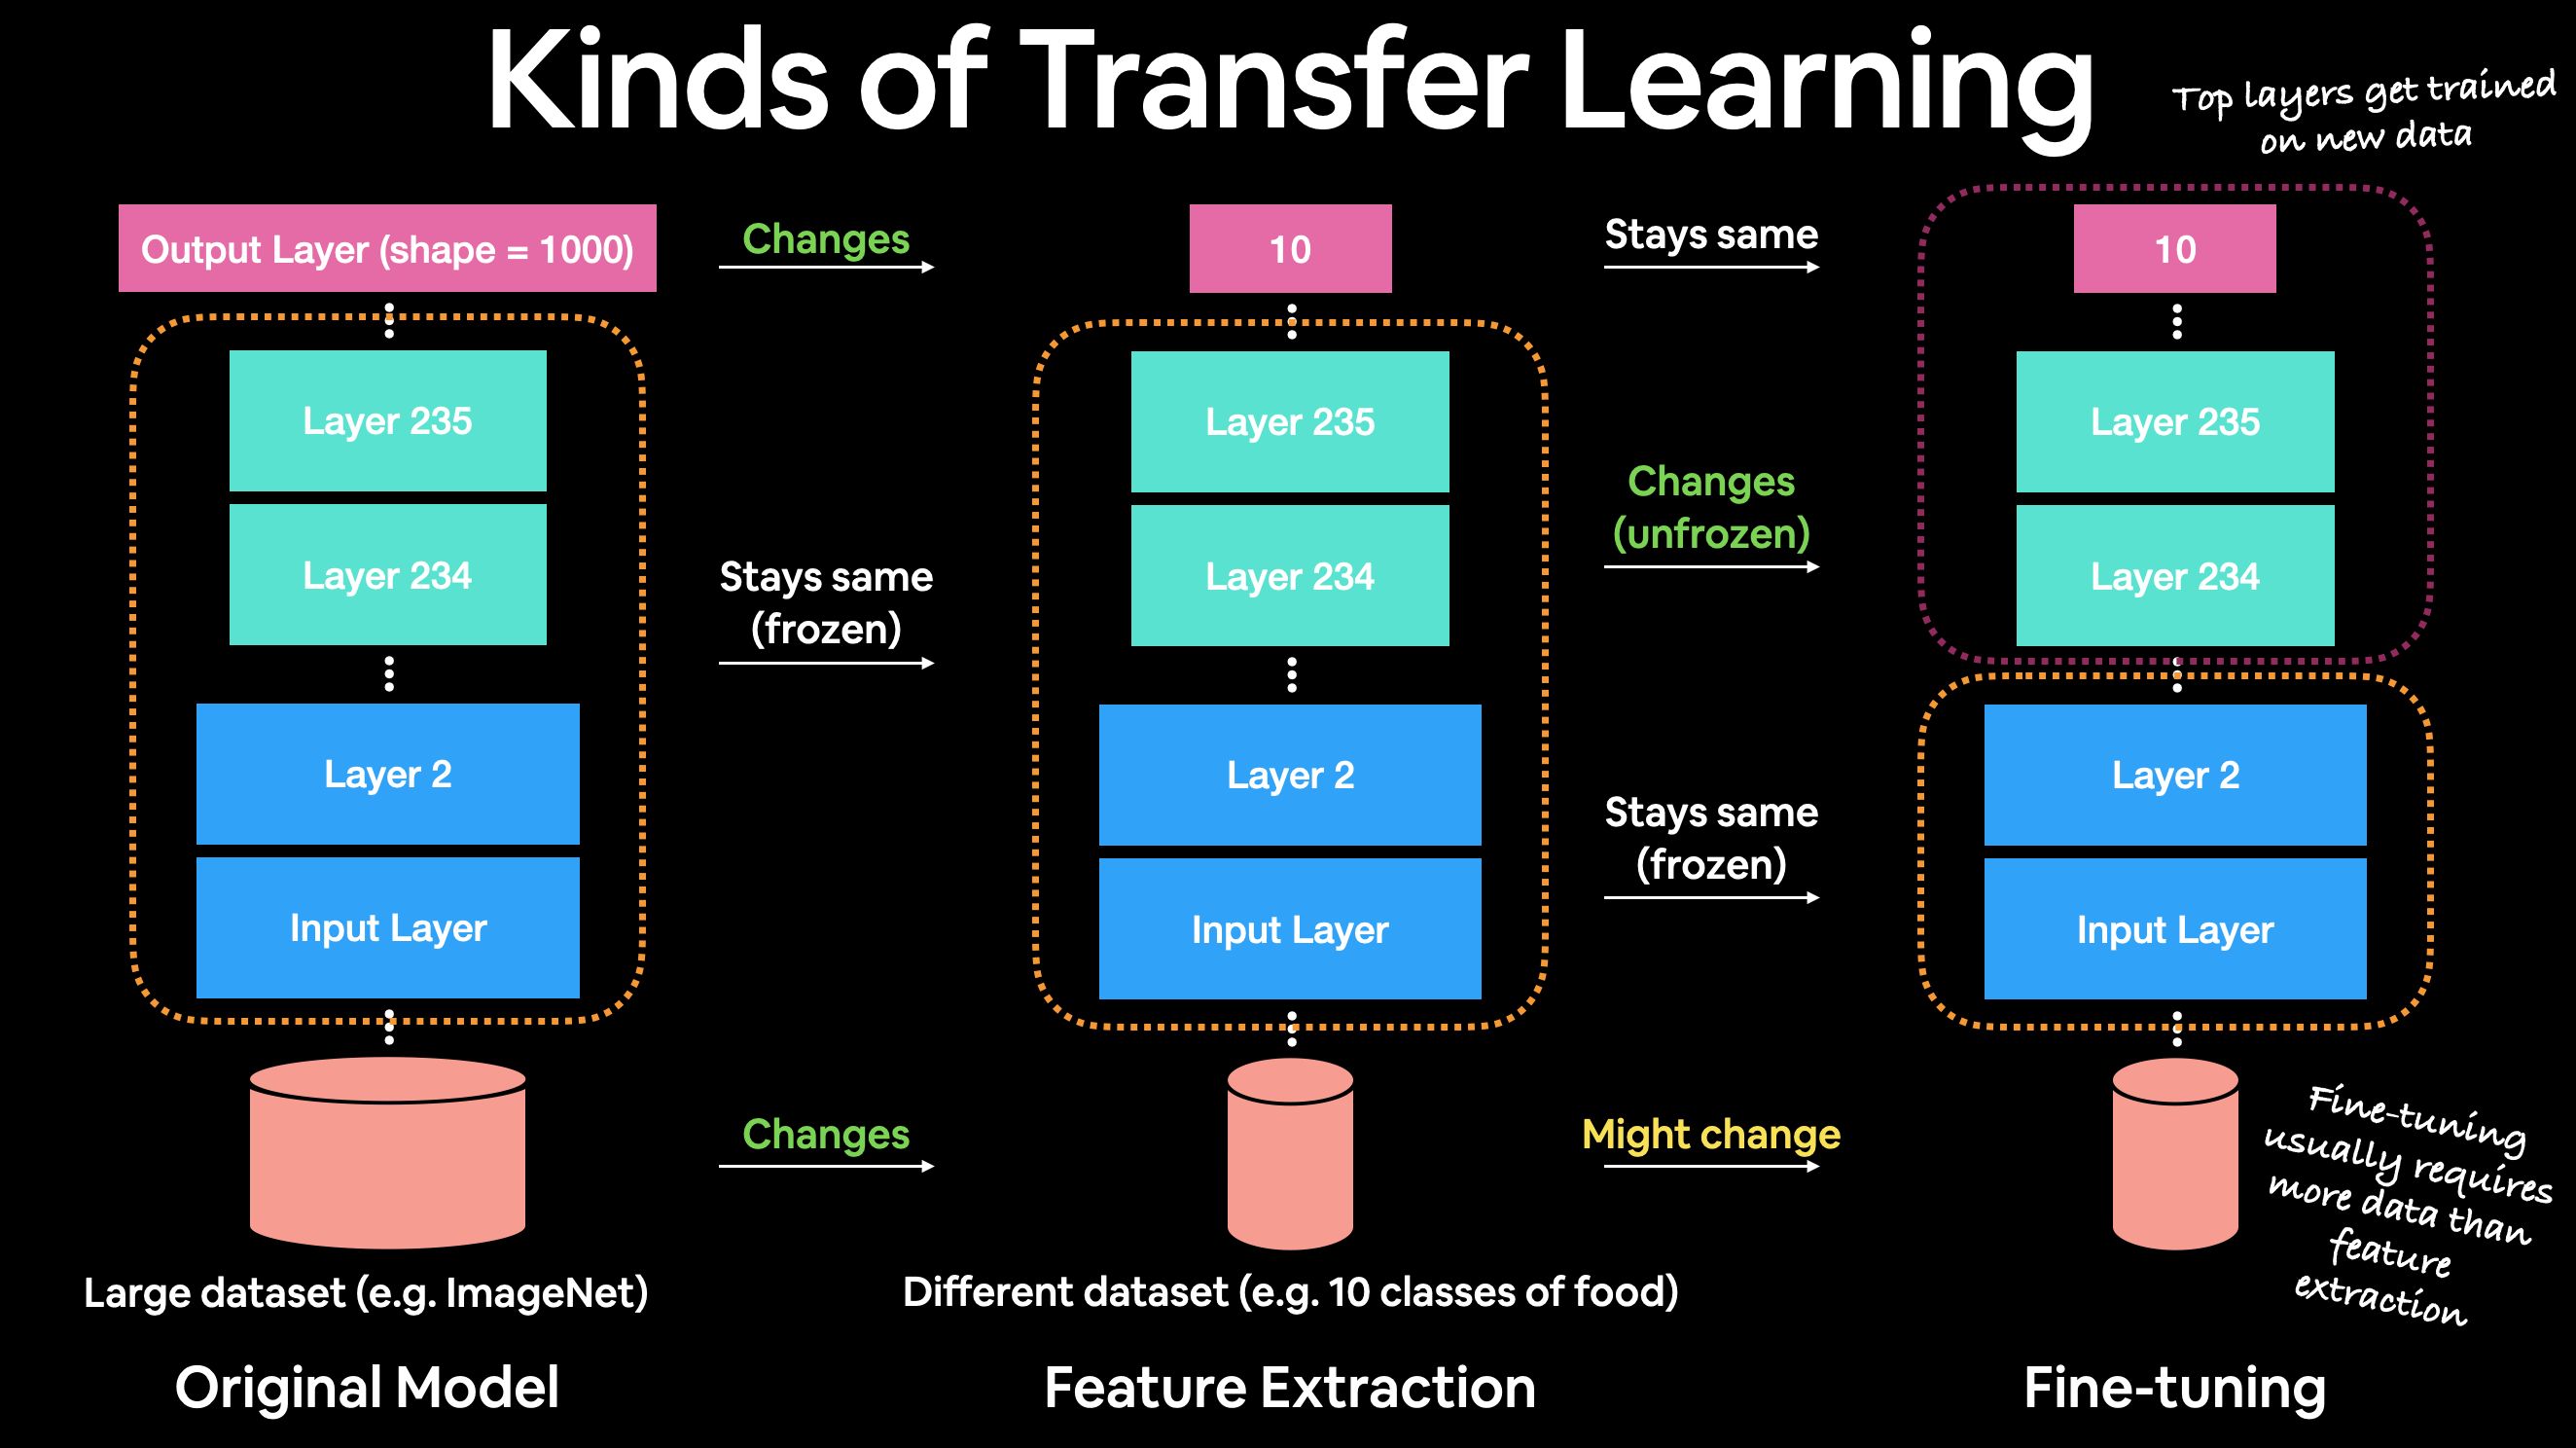

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

# 🔑 Note: Comparing different model architecture performance on the same data is a very common practice. The simple reason is because we want to know which model performs best for your problem.

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

print(tf.__version__)  # Should be at least 2.x
print(hub.__version__) # Should be up-to-date

In [ ]:
# Resnet 50 V2 Feature Extraction.
resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/4"

# Original: EfficientNetB0 feature vector (version 1)
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

# New: EfficientNetB0 Feature vector (version 2)
# efficientnet_url = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet1k_b0/feature_vector/2"

Now, we will save the pre-trained model on TensorFlow Hub. When we use then in our model, the model will automatically be downloaded for us to use. To do this, we can use the `KerasLayer()` model inside the TensorFlow hub Library.

Since, we are going to be comparing two models, to save ourselves code, we will create a function `create_model()` -- this function will take a `model's TensorFlow Hub URL`, instatiate a Keras Sequential model with the appropriate number of output layers and retrun the model.

In [ ]:
def create_model(model_url, num_classes=10):
  """Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url (str): A TensorFlow Hub feature extraction URL.
    num_classes (int): Number of output neurons in output layer,
      should be equal to number of target classes, default 10.

  Returns:
    An uncompiled Keras Sequential model with model_url as feature
    extractor layer and Dense output layer with num_classes outputs.
  """

  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                            trainable=False, # freeze the underlying patterns
                            name = 'feature_extraction_layer',
                            # define the input image shape
                            input_shape = IMAGE_SHAPE + (3,)
                        )

  # Create our own model
  model = tf.keras.Sequential([
    feature_extractor_layer, # use the feature extraction layer as the base
    tf.keras.layers.Dense(num_classes, activation='softmax', name='output_layer') # create our own output layer
  ])

  return model

# Create model.
resnet_model = create_model(resnet_url, num_classes=train_data_10_percent.num_classes)

# Compile.
resnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

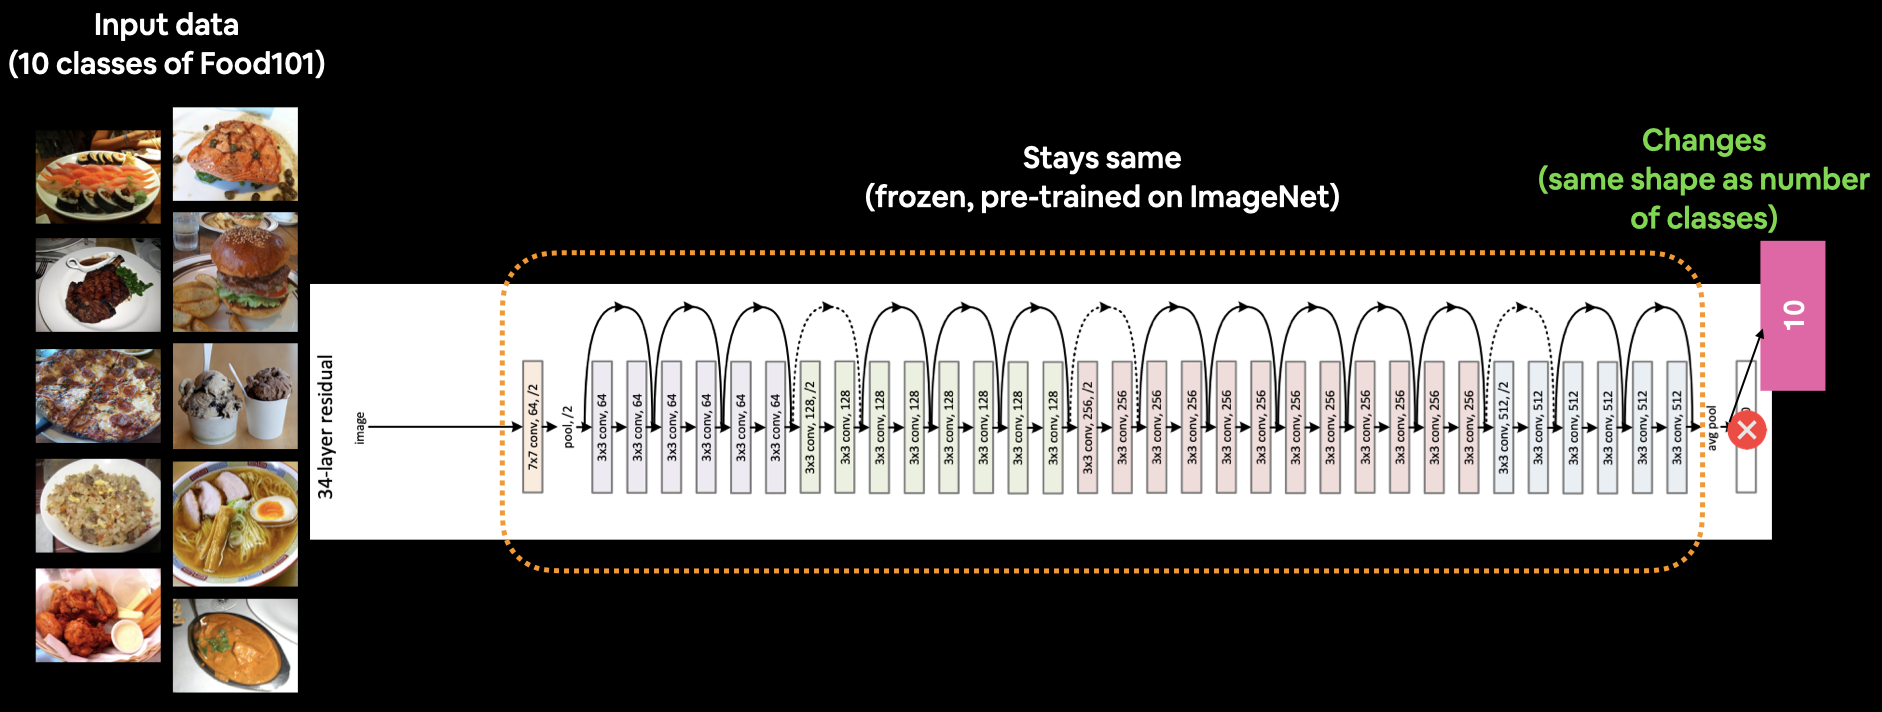

In [ ]:
"""
Before fitting the model, we can add the TensorBoard callbacks to track the performance of our model on TensorBoard.

We can add a callback to our model by using the `callbacks` parameter in the fit function.

In our case, we'll pass the `callbacks` parameter the `create_tensorboard_callback()` we created earlier with some specific inputs so we know what experiments we are running.
"""
# Fit the model.
resnet_history = resnet_model.fit(
    train_data_10_percent,
    epochs=5,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=len(test_data),

    # Adding TensorBoard callback to model (callbacks parameter takes a list).
    callbacks = [
        create_tensorboard_callback(
            dir_name="tensorflow_hub", # save experiments logs here.
            experiment_name="resnet50V2") # name of log files.
    ]
)


It seems that after only `5 epochs`, the `ResNetV250` feature extraction model was able to blow any of the architectures we made out of the water, achieving around `90% accuracy` on the training set and nearly `80% accuracy` on the test set...with only `10 percent` of the training images!

That goes to show the power of transfer learning. And it's one of the main reasons whenever you're trying to model your own datasets, you should look into what pretrained models already exist.

Let's check out our model's training curves using our `plot_loss_curves` function.

In [ ]:
# we can turn this function into a helper function to load in with a helper.py scripts.
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

plot_loss_curves(resnet_history)

In [ ]:
# Resnet summary.
resnet_model.summary()

The feature extraction layer has `23,564,800` parameters which are prelearned patterns the model has already learned on the ImageNet dataset. Since we set `trainable=False`, these patterns `remain frozen` (`non-trainable`) during training.

This means during training the model updates the `20,490` parameters in the output layer to suit our dataset.



The setup will be the exact same as before, except for the `model_url` parameter in the `create_model()` function and the `experiment_name` parameter in the `create_tensorboard_callback()` function.

In [ ]:
# Create a model.
efficientnet_model = create_model(model_url = efficientnet_url, # use EfficientNetB0 TensorFlow Hub URL.
             num_classes=train_data_10_percent.num_classes)

efficientnet_model

In [ ]:
# Compile EfficientNet Model.
efficientnet_model.compile(loss='categorical_crossentropy',
                           optimizer=tf.keras.optimizers.Adam(),
                           metrics=['accuracy'])

In [ ]:
# Fit EfficientNet Model.
efficientnet_history = efficientnet_model.fit(
    train_data_10_percent, # Only use 10% of training data.
    epochs=5, # train for 5 epochs.
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=len(test_data),

    # setting the callbacks function here.
    callbacks=[
        create_tensorboard_callback(
            dir_name="tensorflow_hub",
            # Track logs under different experiment name.
            experiment_name="efficientnetB0"
        )
    ]
)

The EfficientNetB0 model does even better than the ResNetV250 model! Achieving over 85% accuracy on the test set...again with only 10% of the training data.

In [ ]:
plot_loss_curves(efficientnet_history)

In [ ]:
efficientnet_model.summary()

### Comparing models using TensorBoard

To track the experiment having more than two models, we can use the google `TensorBoard`.

since, we set up a TensorBoard callback, all of our model's training logs have been saved automatically. To visualize them, we can upload the results to TensorBoard.dev.

#### Uploading experiments to TensorBoard

In [ ]:
# To upload a series of TensorFlow logs to TensorBoard, we can use the following command:
# Upload TensorBoard dev records

# !tensorboard dev upload --logdir ./tensorflow_hub/ \
#   --name "EfficientNetB0 vs. ResNet50V2" \
#   --description "Comparing two different TF Hub feature extraction models architectures using 10% of training images" \
#   --one_shot

# --logdir --> is the target upload directory.
# --name --> is the name of the experiment.
# --description --> is a brief description of the experiment.
# --one_shot --> exist the TensorBoard uploader once uploading is finished.

# Running the tensorboard dev upload command will first ask us to authorize the upload to TensorBoard.dev After we authorized the upload, log files will be uploaded.

#### Upload TensorBoard dev records ####

# !tensorboard dev upload --logdir ./tensorflow_hub/ \
#   --name "EfficientNetB0 vs. ResNet50V2" \
#   --description "Comparing two different TF Hub feature extraction models architectures using 10% of training images" \
#   --one_shot

### Listing experiments you've saved to TensorBoard

In [ ]:
# To see all of the experiments we have uploaded we can use the command:
# tensorboard dev list

# Check out experiments
# !tensorboard dev list

### Deleting experiments from TensorBoard

In [ ]:
# All uploads to TensorBoard.dev are public, so to delete an experiment you can use the command:

# tensorboard dev delete --experiment_id [INSERT_EXPERIMENT_ID]

# # Delete an experiment
# !tensorboard dev delete --experiment_id ...enter_your_experiment_id...

In [ ]:
# Check to see if experiments still exist
# !tensorboard dev list

### 🛠 Exercises